Juupyter notebook for simple data analysis of output files from Gaussian, cdftT, pySCF (.cube and density matrix)

In [513]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import os


def list2array(list_) :
    data = list()
    for line in list_ :
        data.append(line.split())
    data = np.array(data,dtype=np.float64).flatten()
    return data

def readRDM(fname,nMo) :
    with open(fname, 'r') as file:
        lines = file.readlines()

    alpha = list2array(lines[1:nMo+1])
    alpha.resize((nMo,nMo))

    beta = list2array(lines[nMo+3:2*nMo+3])
    beta.resize((nMo,nMo))

    return alpha,beta

Get transitions used by pySCF (matrix elements of X produced by pySCF_DensityMatrix and pySCF_TransitionDensityMatrix)

In [487]:
fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/transitions/pySCF/X_state_11.npy"
py_X = np.load(fname)
nocc,nvir = np.shape(py_X)
print(f'n_occupied = {nocc}, n_virtual = {nvir} \n')

n_transitions = 10
a = np.abs(py_X)
for i in range(n_transitions):
    val = np.max(np.max(a))
    pos = np.argmax(a)
    print(f'transition {int(np.floor(pos/nvir)+1)}->{pos%nvir+nocc+1} with coef {val:.5f}')
    a[int(np.floor(pos/nvir)),pos%nvir]=0
print("")

with np.printoptions(precision=3,suppress=True):
    print(py_X)

n_occupied = 7, n_virtual = 3 

transition 7->10 with coef 0.49128
transition 4->10 with coef 0.44872
transition 6->9 with coef 0.15604
transition 5->8 with coef 0.15604
transition 3->10 with coef 0.09105
transition 6->8 with coef 0.01219
transition 5->9 with coef 0.01219
transition 2->10 with coef 0.00224
transition 1->10 with coef 0.00008
transition 3->9 with coef 0.00000

[[-0.    -0.     0.   ]
 [-0.     0.     0.002]
 [-0.     0.    -0.091]
 [-0.    -0.     0.449]
 [ 0.156 -0.012  0.   ]
 [ 0.012  0.156 -0.   ]
 [ 0.    -0.    -0.491]]


compare 2 RDM

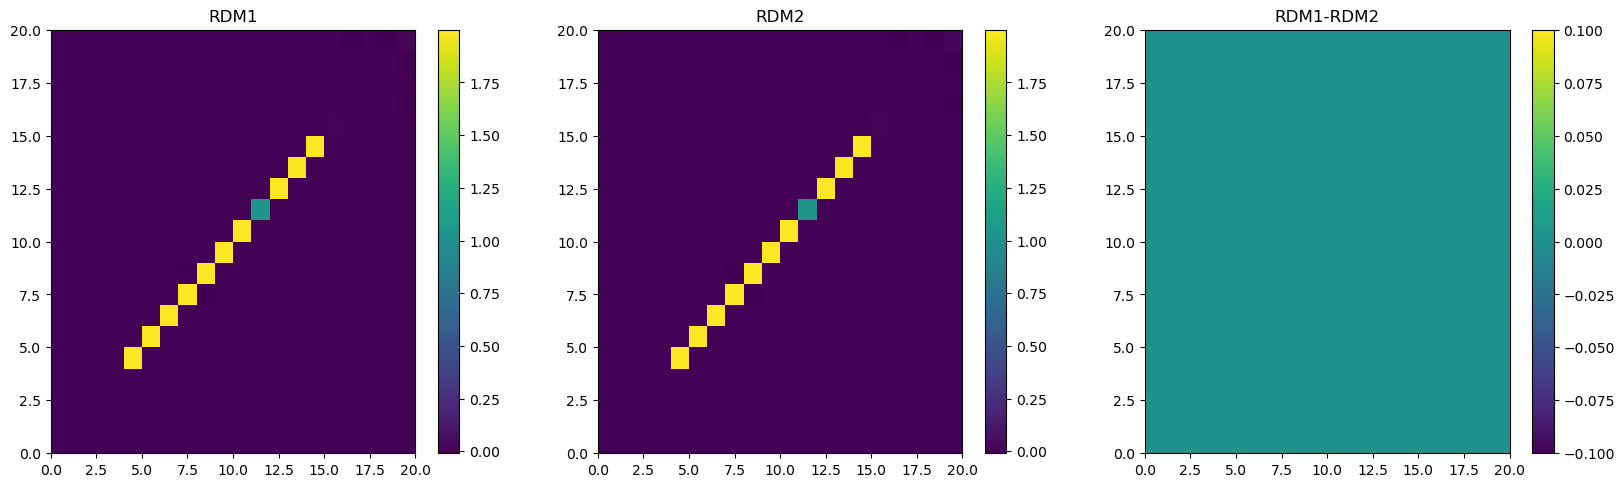

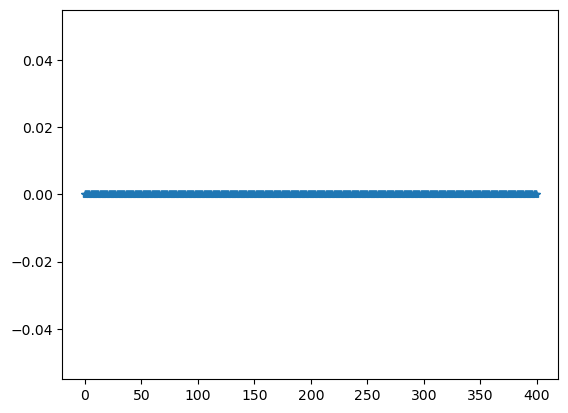

In [481]:
##################
# RDM from CdftT #
##################
f1 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/cpp/cpp_Gamma_state50_RDM.cdftt")
f2 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/cpp/cpp_Gamma_transition_state50_state50_RDM.cdftt")
Nmo = 80          # number of molecular orbitals i.e. size of matrix

tokens = f1.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=2 :
        row = token
        data.append(row)
CdftTRDM1 = np.array(data[0:Nmo**2],dtype=float)*2

tokens = f2.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=2 :
        row = token
        data.append(row)
CdftTRDM2 = np.array(data[0:Nmo**2],dtype=float)

CdftTRDM1.resize((Nmo,Nmo))
CdftTRDM2.resize((Nmo,Nmo))


##################
# RDM from pySCF #
##################
fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/pySCF/RDM_state_1.npy"
pyRDM = np.load(fname)



########
# plot #
########
RDM1 = CdftTRDM1[0:20,0:20]
RDM2 = CdftTRDM2[0:20,0:20]*2

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))
plot1 = ax[0].pcolormesh(RDM1)
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(RDM2)
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(RDM1-RDM2)
plt.colorbar(plot3)
ax[0].set_title('RDM1')
ax[1].set_title('RDM2')
ax[2].set_title('RDM1-RDM2')
plt.show()


plt.plot(RDM1.flatten()-RDM2.flatten(),"*")
plt.show()

Transition matrix from Gaussian .fchk

In [ ]:
# Gaussian .fchk file
fchk_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/input/acrolein_100.fchk"
# CdftT file
CdftT_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/cpp/cpp_Gamma_transition_state0_state10_RDM.cdftt"
# pySCF file
pySCF_fname = None #"/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/pySCF/T_RDM_state_10.npy"

##############
# read .fchk #
##############
nMo     = 80
nStates = 100
nSpins  = 2

#read gaussian fchk file
with open(fchk_fname, 'r') as file:
    lines = file.readlines()

i = 0
for line in lines:
    i += 1
    if line[0:22] == 'G to E trans densities' :
        start = i
    if line[0:16] == 'Mulliken Charges' :
        end = i-1
data = list2array(lines[start:end])

#resize to obtain 1 matrix per state and spin type
#trans_dens[spin,state] is a nMo x nMo transition density matrix corresponding to an excited state (0 indexed) and spin
trans_dens = np.empty(shape=(nSpins,nStates,nMo,nMo))
for state in range(nStates) :
    for spin in range(nSpins) :
        k = nSpins*state + spin
        tmp = data[nMo**2*k:nMo**2*(k+1)]
        tmp.resize((nMo,nMo))
        trans_dens[spin,state] = tmp

#read MO coefficients matrix to for MO->AO conversion of CdftT RDM 
i = 0
beta_read = False  # check if alphas and betas treated separately
for line in lines:
    i += 1
    if line[0:21] == 'Alpha MO coefficients' :
        startA = i
    if line[0:20] == 'Beta MO coefficients' :
        startB = i
        beta_read = True
    if line[0:17] == 'Orthonormal basis' :
        orthobasis = i
        
if beta_read :
    AlphaMoCoefs = list2array(lines[startA:startB-1])
    AlphaMoCoefs.resize((nMo,nMo))
    BetaMoCoefs  = list2array(lines[startB:2*startB-startA-1])
    BetaMoCoefs.resize((nMo,nMo))
else :
    AlphaMoCoefs = list2array(lines[startA:orthobasis-1])
    AlphaMoCoefs.resize((nMo,nMo))
    BetaMoCoefs = AlphaMoCoefs


#########################
# read CdftT RDM matrix #
#########################
alphaGamma,betaGamma = readRDM(CdftT_fname,nMo)

#########################
# read pySCF RDM matrix #
#########################
if pySCF_fname!=None:
    pySCF_trans_dens = np.load(pySCF_fname)
else:
    pySCF_trans_dens = np.empty(0)

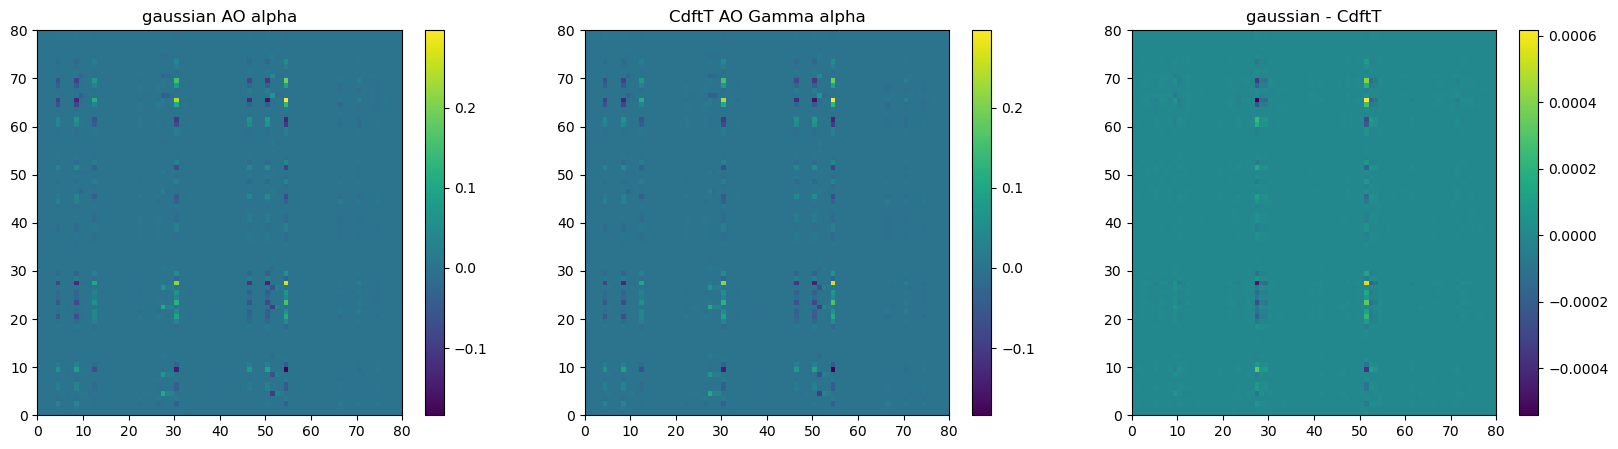

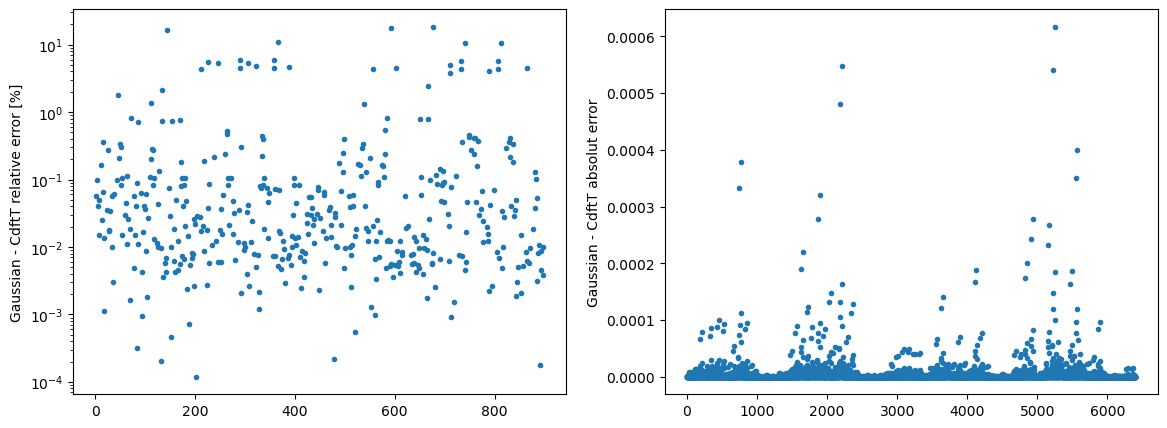

In [502]:
#####################################
# compare Gaussian-CdftT (AO basis) #
#####################################

#choose a Gaussian RDM
alphaG = trans_dens[0,9]
betaG  = trans_dens[1,9]

#convert MO to AO for CdftT RDM
AO_alphaGamma = np.matmul(np.matmul(np.transpose(AlphaMoCoefs),alphaGamma),AlphaMoCoefs)
AO_betaGamma = np.matmul(np.matmul(np.transpose(BetaMoCoefs),betaGamma),BetaMoCoefs)

#get same norm on Gaussian and CdftT
normac = np.sqrt(np.sum(AO_alphaGamma**2))
normag = np.sqrt(np.sum(alphaG**2))
AO_alphaGamma *= normag/normac
normbc = np.sqrt(np.sum(AO_betaGamma**2))
normbg = np.sqrt(np.sum(betaG**2))
AO_betaGamma *= normbg/normbc

plot = 'alpha'
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5))
if plot=='alpha':
    plot1 = ax[0].pcolormesh(alphaG)
    plot2 = ax[1].pcolormesh(AO_alphaGamma)
    plot3 = ax[2].pcolormesh(alphaG-AO_alphaGamma)
    ax[0].set_title('gaussian AO alpha')
    ax[1].set_title('CdftT AO Gamma alpha')
if plot=='beta':
    plot1 = ax[0].pcolormesh(betaG)
    plot2 = ax[1].pcolormesh(AO_betaGamma)
    plot3 = ax[2].pcolormesh(betaG-AO_betaGamma)
    ax[0].set_title('gaussian AO beta')
    ax[1].set_title('CdftT AO Gamma beta')

plt.colorbar(plot1)
plt.colorbar(plot2)
plt.colorbar(plot3)
ax[2].set_title('gaussian - CdftT')
plt.show()

treshold = 0.001  #consider only coefs above treshold for relative error
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(14,5))
ax[0].plot(np.abs(alphaG[np.abs(alphaG)>treshold].flatten()-AO_alphaGamma[np.abs(alphaG)>treshold].flatten())/alphaG[np.abs(alphaG)>treshold].flatten()*100,'.')
ax[0].set_ylabel('Gaussian - CdftT relative error [%]')
ax[0].set_yscale('log')
ax[1].plot(np.abs(alphaG.flatten()-AO_alphaGamma.flatten()),'.')
ax[1].set_ylabel('Gaussian - CdftT absolut error')
plt.show()

In [ ]:
##################################
# compare pySCF-CdftT (MO basis) #
##################################
norma = np.sqrt(np.sum(alphaGamma**2))
normb = np.sqrt(np.sum(betaGamma**2))
alphaGamma/=norma
betaGamma/=normb

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5))
plot1 = ax[0].pcolormesh(pySCF_trans_dens)
plot2 = ax[1].pcolormesh(alphaGamma)
plot3 = ax[2].pcolormesh(pySCF_trans_dens-alphaGamma)
plt.colorbar(plot1)
plt.colorbar(plot2)
plt.colorbar(plot3)
ax[0].set_title('pySCF')
ax[1].set_title('cpp MO')
ax[2].set_title('pySCF - CdftT')
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(20,7.5))
ax[0].plot(pySCF_trans_dens.flatten(),'*',label='pySCF')
ax[0].plot(alphaGamma.flatten(),'.',label='alphaGamma')
ax[0].plot(betaGamma.flatten(),'.',label='betaGamma')
ax[0].legend()
ax[1].plot(pySCF_trans_dens.flatten()-alphaGamma.flatten())
ax[1].set_ylabel('pySCF - CdftT')
plt.show()


CUBE file comparison

In [504]:
########################
# read both cube files #
########################
f1= open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/cpp/cpp_Gamma_state50.cube")
f2 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/Gaussian/acroleinEx50.cube")

tokens = f1.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=62 :                            #ignore header
        row = token
        data.append(row)
densitycpp = np.array(data,dtype=float)

tokens = f2.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=68 :
        row = token
        data.append(row)
densitygaussian = np.array(data,dtype=float)

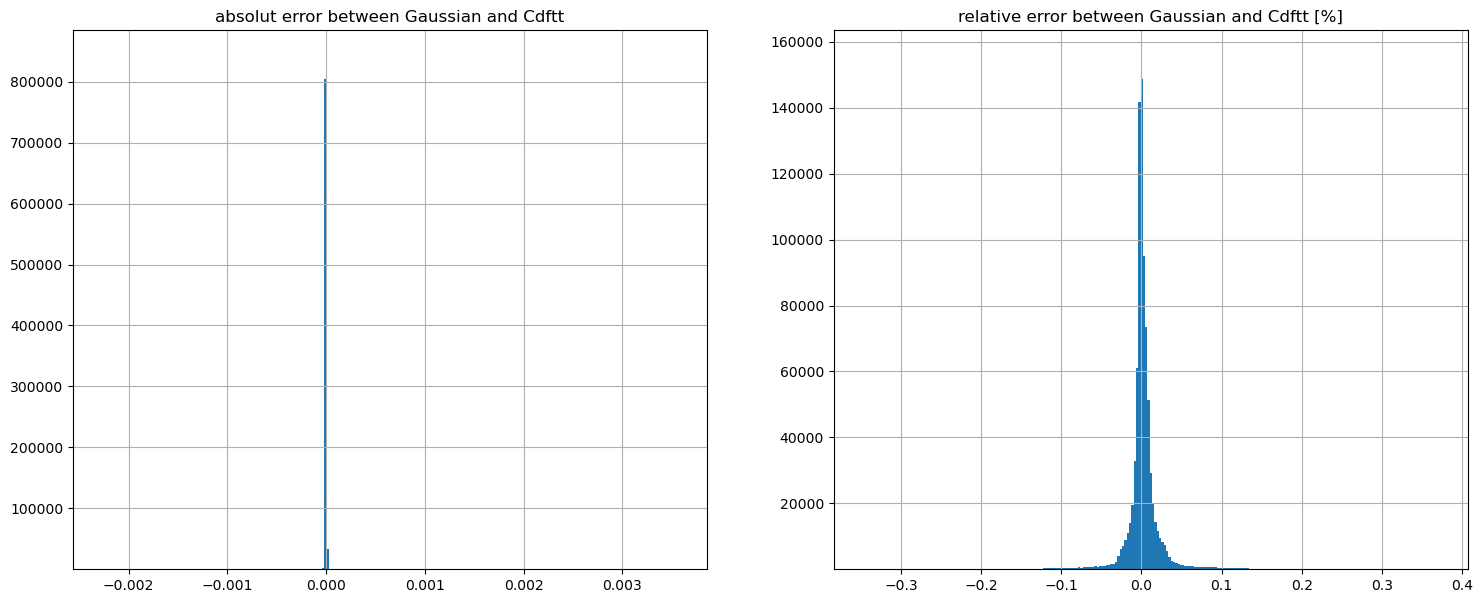

In [510]:
####################
# create histogram #
####################

#densitycpp = -densitycpp
treshold = 1e-7
err = (densitycpp - densitygaussian)
rel_err = err[np.abs(densitygaussian)>treshold]/densitygaussian[np.abs(densitygaussian)>treshold]*100

scale = 'linear'  #log or linear
bins     = np.linspace(np.min(err),np.max(err),250)
rel_bins = np.linspace(np.min(rel_err),np.max(rel_err),250)

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(18,7))
plot1 = ax[0].hist(err,bins=bins)
plot2 = ax[1].hist(rel_err,bins=rel_bins)
if scale=='log':
    ax[0].set_ylim([0.1,plot1[0].max()*10.1])
    ax[1].set_ylim([0.1,plot2[0].max()*10.1])
if scale=='linear':
    ax[0].set_ylim([0.1,plot1[0].max()*1.1])
    ax[1].set_ylim([0.1,plot2[0].max()*1.1])
ax[0].set_title("absolut error between Gaussian and Cdftt")
ax[1].set_title("relative error between Gaussian and Cdftt [%]")
ax[0].set_yscale(scale)
ax[1].set_yscale(scale)
ax[0].grid()
ax[1].grid()
plt.show()

Read .fchk GS electronic density

In [516]:
################################################################
# convert upper triangular list of coefs into symmetric matrix #
################################################################

fchk_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/input/CO_TDDFT_STO-3G_TDA_SCF_CUBE.fchk"
nMo = 10

#read gaussian fchk file
with open(fchk_fname, 'r') as file:
    lines = file.readlines()

i=0
for line in lines:
    i += 1
    if line[0:17] == 'Total SCF Density' :
        start = i
    if line[0:12] == 'Total CI Rho' :
        end = i-1
GSAOdensity_flat = list2array(lines[start:end])

GSAOdensity      = np.zeros(shape=(nMo,nMo))
p = 0
k = 0
l = nMo
for p in range(nMo):
    GSAOdensity[p:,p]= GSAOdensity_flat[k:k+l]
    k=k+l
    l-=1
for p in range(nMo):
    for q in range(nMo) :
        if p>q :
            GSAOdensity[q,p] = GSAOdensity[p,q]


with np.printoptions(precision=8,suppress=True,linewidth=250):
    print(GSAOdensity)
                

[[ 2.11924873 -0.45945299  1.97310533  0.          0.          0.44852936  0.          0.          0.          0.44852936]
 [-0.45945299  0.13409584 -0.66241044  0.          0.          0.64774137  0.00995669  0.0315648   0.          0.        ]
 [ 1.97310533 -0.66241044 -0.0680621   2.11162208  0.00952261 -0.36069747  0.          0.          0.10955167 -0.46638818]
 [ 0.          0.          2.11162208  2.08492328  0.          0.          0.73302103  0.          0.          0.        ]
 [ 0.          0.          0.00952261  0.          0.          1.19795908  0.          0.          0.          0.73302103]
 [ 0.44852936  0.64774137 -0.36069747  0.          1.19795908  0.          0.          0.          0.          1.19795908]
 [ 0.          0.00995669  0.          0.73302103  0.          0.          0.10735336 -0.0598944   0.          0.        ]
 [ 0.          0.0315648   0.          0.          0.          0.         -0.0598944  -0.68023494 -0.07732454  0.4697975 ]
 [ 0.          0